In [1]:
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt

In [6]:
def load_data():
    total_data = []
    
    for dirname in os.listdir(data_root_dir):
        if dirname.endswith('.npy') or dirname.endswith('.json'):
            continue
        if dirname == 'img':
            continue
        # extract parameters from the directory name
        match = re.match(r'w_in_amp_(\d+)p(\d+)_gbar_(\d+)p(\d+)', dirname)
        w_in_amp = eval(f"{match.group(1)}.{match.group(2)}")
        gbar = eval(f"{match.group(3)}.{match.group(4)}")
        print(f"Processing: {dirname} with w_in_amp={w_in_amp}, gbar={gbar}")
        # load the data
        data = {}
        data['w_in_amp'] = w_in_amp
        data['gbar'] = gbar
        data['dirname'] = dirname
        data['output_train'] = np.load(os.path.join(data_root_dir, dirname, 'output_data_train.npy'))
        data['output_test'] = np.load(os.path.join(data_root_dir, dirname, 'output_data_test.npy'))
        total_data.append(data)
    return total_data

(500000, 3)


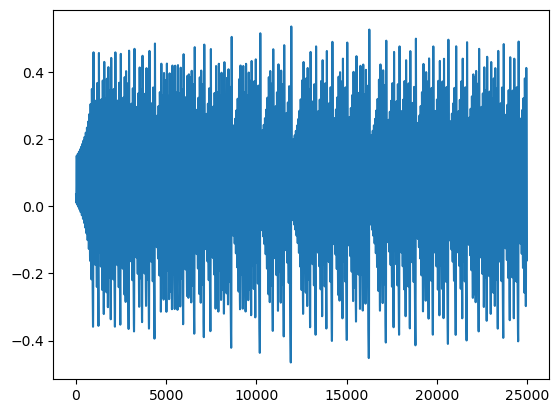

In [4]:
import sys

sys.path.append(os.path.join(os.getcwd(), '..'))

from ml_force import LorenzAttractor, minmax_transform, z_transform

seed = 1
np.random.seed(seed)

T = 25_000
dt = 5e-2
t = np.arange(0, T, dt)
nt = t.size
la = LorenzAttractor(T, dt, tau=.01)
x = la.generate(transient_time=500.0)

x = x.T
sup = minmax_transform(x, zero_mean=True)
sup = np.load(os.path.join(data_root_dir, 'supervisor.npy'))
# sup = z_transform(x)
print(sup.shape)

plt.plot(t, sup[:, 2])
plt.show()

/home/ali/Code/research/ml_force_research/hpc/bfm_output/lorenz_current_grand


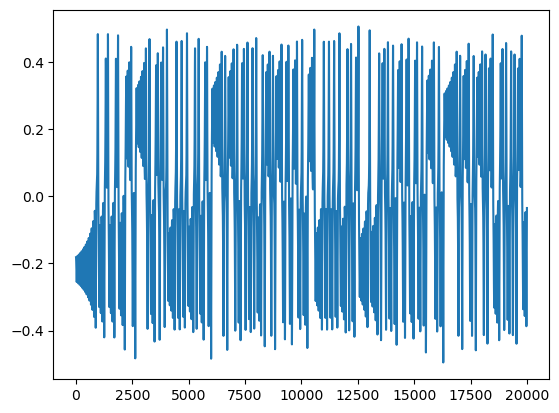

In [2]:
import re


data_root_dir = os.path.join(os.getcwd(), 'bfm_output', 'lorenz_current_grand')
print(data_root_dir)

sup = np.load(os.path.join(data_root_dir, 'supervisor.npy'))

dt = 1e-1
nt = sup.shape[0]
t_vec = np.arange(nt) * dt


plt.plot(t_vec, sup[:, 0], label='x')
plt.show()

In [3]:
nt_split = int(nt / 2)
sup_test = sup[nt_split:]
sup_train = sup[:nt_split]

In [23]:
from scipy.signal import find_peaks

def get_return_map(data):
    peaks = data[find_peaks(data, distance=600)[0]]
    # peaks = peaks[peaks > 0]
    return_map = np.vstack([peaks[:-1], peaks[1:]])
    return return_map

In [32]:

def get_histogram(output_data, sup_test, n_bins=100):
    """
    Get histogram of data.
    """
    hists = []
    for axis in range(sup.shape[1]):
        sup_hist, bins = np.histogram(sup_test[:, axis], bins=n_bins, density=True)
        output_hist, bins = np.histogram(output_data[:, axis], bins=bins, density=True)
        hists.append((sup_hist, output_hist, bins))
    return hists

In [33]:
def kl_div(hists: list[tuple]):
    """
    Calculate the KL divergence between two multi-dimensional histograms.
    """
    kl_div_values = []
    for i in range(len(hists)):
        sup_hist, output_hist, bins = hists[i]
        bin_size = bins[1] - bins[0]
        # Ensure both histograms are normalized
        sup_hist = sup_hist / np.sum(sup_hist) * bin_size
        output_hist = output_hist / np.sum(output_hist) * bin_size
        # Avoid division by zero and log of zero
        sup_hist = np.where(sup_hist == 0, 1e-10, sup_hist)
        output_hist = np.where(output_hist == 0, 1e-10, output_hist)
        # Calculate KL divergence
        kl_div_value = np.sum(sup_hist * np.log(sup_hist / output_hist))
        kl_div_values.append(kl_div_value)
        
    return kl_div_values

In [34]:
metrics = []

for dirname in os.listdir(data_root_dir):
    if dirname.endswith('.npy') or dirname.endswith('.json'):
        continue
    if dirname == 'img':
        continue
    # extract parameters from the directory name
    match = re.match(r'w_in_amp_(\d+)p(\d+)_gbar_(\d+)p(\d+)', dirname)
    if not match:
        continue
    w_in_amp = eval(f"{match.group(1)}.{match.group(2)}")
    gbar = eval(f"{match.group(3)}.{match.group(4)}")
    print(f"Processing: {dirname} with w_in_amp={w_in_amp}, gbar={gbar}")
    # load the data
    data = {}
    data['Q'] = w_in_amp
    data['gbar'] = gbar
    data['dirname'] = dirname
    
    output_test = np.load(os.path.join(data_root_dir, dirname, 'output_data_test.npy'))
    data['kl_div'] = kl_div(get_histogram(output_test, sup_test))
    data['return_map'] = get_return_map(output_test[:, -1])
    metrics.append(data)

Processing: w_in_amp_20p0000_gbar_10p8333 with w_in_amp=20.0, gbar=10.8333
Processing: w_in_amp_20p0000_gbar_5p0000 with w_in_amp=20.0, gbar=5.0
Processing: w_in_amp_20p0000_gbar_16p6667 with w_in_amp=20.0, gbar=16.6667
Processing: w_in_amp_20p0000_gbar_22p5000 with w_in_amp=20.0, gbar=22.5
Processing: w_in_amp_20p0000_gbar_28p3333 with w_in_amp=20.0, gbar=28.3333
Processing: w_in_amp_20p0000_gbar_34p1667 with w_in_amp=20.0, gbar=34.1667
Processing: w_in_amp_20p0000_gbar_40p0000 with w_in_amp=20.0, gbar=40.0
Processing: w_in_amp_67p7778_gbar_10p8333 with w_in_amp=67.7778, gbar=10.8333
Processing: w_in_amp_67p7778_gbar_16p6667 with w_in_amp=67.7778, gbar=16.6667
Processing: w_in_amp_67p7778_gbar_22p5000 with w_in_amp=67.7778, gbar=22.5
Processing: w_in_amp_67p7778_gbar_28p3333 with w_in_amp=67.7778, gbar=28.3333
Processing: w_in_amp_67p7778_gbar_34p1667 with w_in_amp=67.7778, gbar=34.1667
Processing: w_in_amp_67p7778_gbar_40p0000 with w_in_amp=67.7778, gbar=40.0
Processing: w_in_amp_115

In [43]:
len(metrics)

69

In [35]:
total_sorted = sorted(metrics, key=lambda x: x['Q'])

def sort_stacked(total_sorted):
    total_stacked = []
    Qs = [data['Q'] for data in total_sorted]
    for value in np.unique(Qs):
        dummy = list()
        for data in total_sorted:
            if data['Q'] == value:
                dummy.append(data)
        total_stacked.append(sorted(dummy, key=lambda x: x['gbar']))

    for lst in total_stacked:
        for data in lst:
            print(f"{data['Q']}, {data['gbar']}")
    return total_stacked

total_stacked = sort_stacked(total_sorted)

20.0, 5.0
20.0, 10.8333
20.0, 16.6667
20.0, 22.5
20.0, 28.3333
20.0, 34.1667
20.0, 40.0
67.7778, 10.8333
67.7778, 16.6667
67.7778, 22.5
67.7778, 28.3333
67.7778, 34.1667
67.7778, 40.0
115.5556, 5.0
115.5556, 10.8333
115.5556, 16.6667
115.5556, 22.5
115.5556, 28.3333
115.5556, 34.1667
115.5556, 40.0
163.3333, 5.0
163.3333, 10.8333
163.3333, 16.6667
163.3333, 22.5
163.3333, 28.3333
163.3333, 34.1667
163.3333, 40.0
211.1111, 5.0
211.1111, 10.8333
211.1111, 16.6667
211.1111, 22.5
211.1111, 28.3333
211.1111, 34.1667
211.1111, 40.0
258.8889, 5.0
258.8889, 10.8333
258.8889, 16.6667
258.8889, 22.5
258.8889, 28.3333
258.8889, 34.1667
258.8889, 40.0
306.6667, 5.0
306.6667, 10.8333
306.6667, 16.6667
306.6667, 22.5
306.6667, 28.3333
306.6667, 34.1667
306.6667, 40.0
354.4444, 5.0
354.4444, 10.8333
354.4444, 16.6667
354.4444, 22.5
354.4444, 28.3333
354.4444, 34.1667
354.4444, 40.0
402.2222, 5.0
402.2222, 10.8333
402.2222, 16.6667
402.2222, 22.5
402.2222, 28.3333
402.2222, 34.1667
402.2222, 40.0
450.

In [36]:
save_dir = os.path.join(data_root_dir, 'img')

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

In [37]:
original_return_map = get_return_map(sup_test[:, -1])

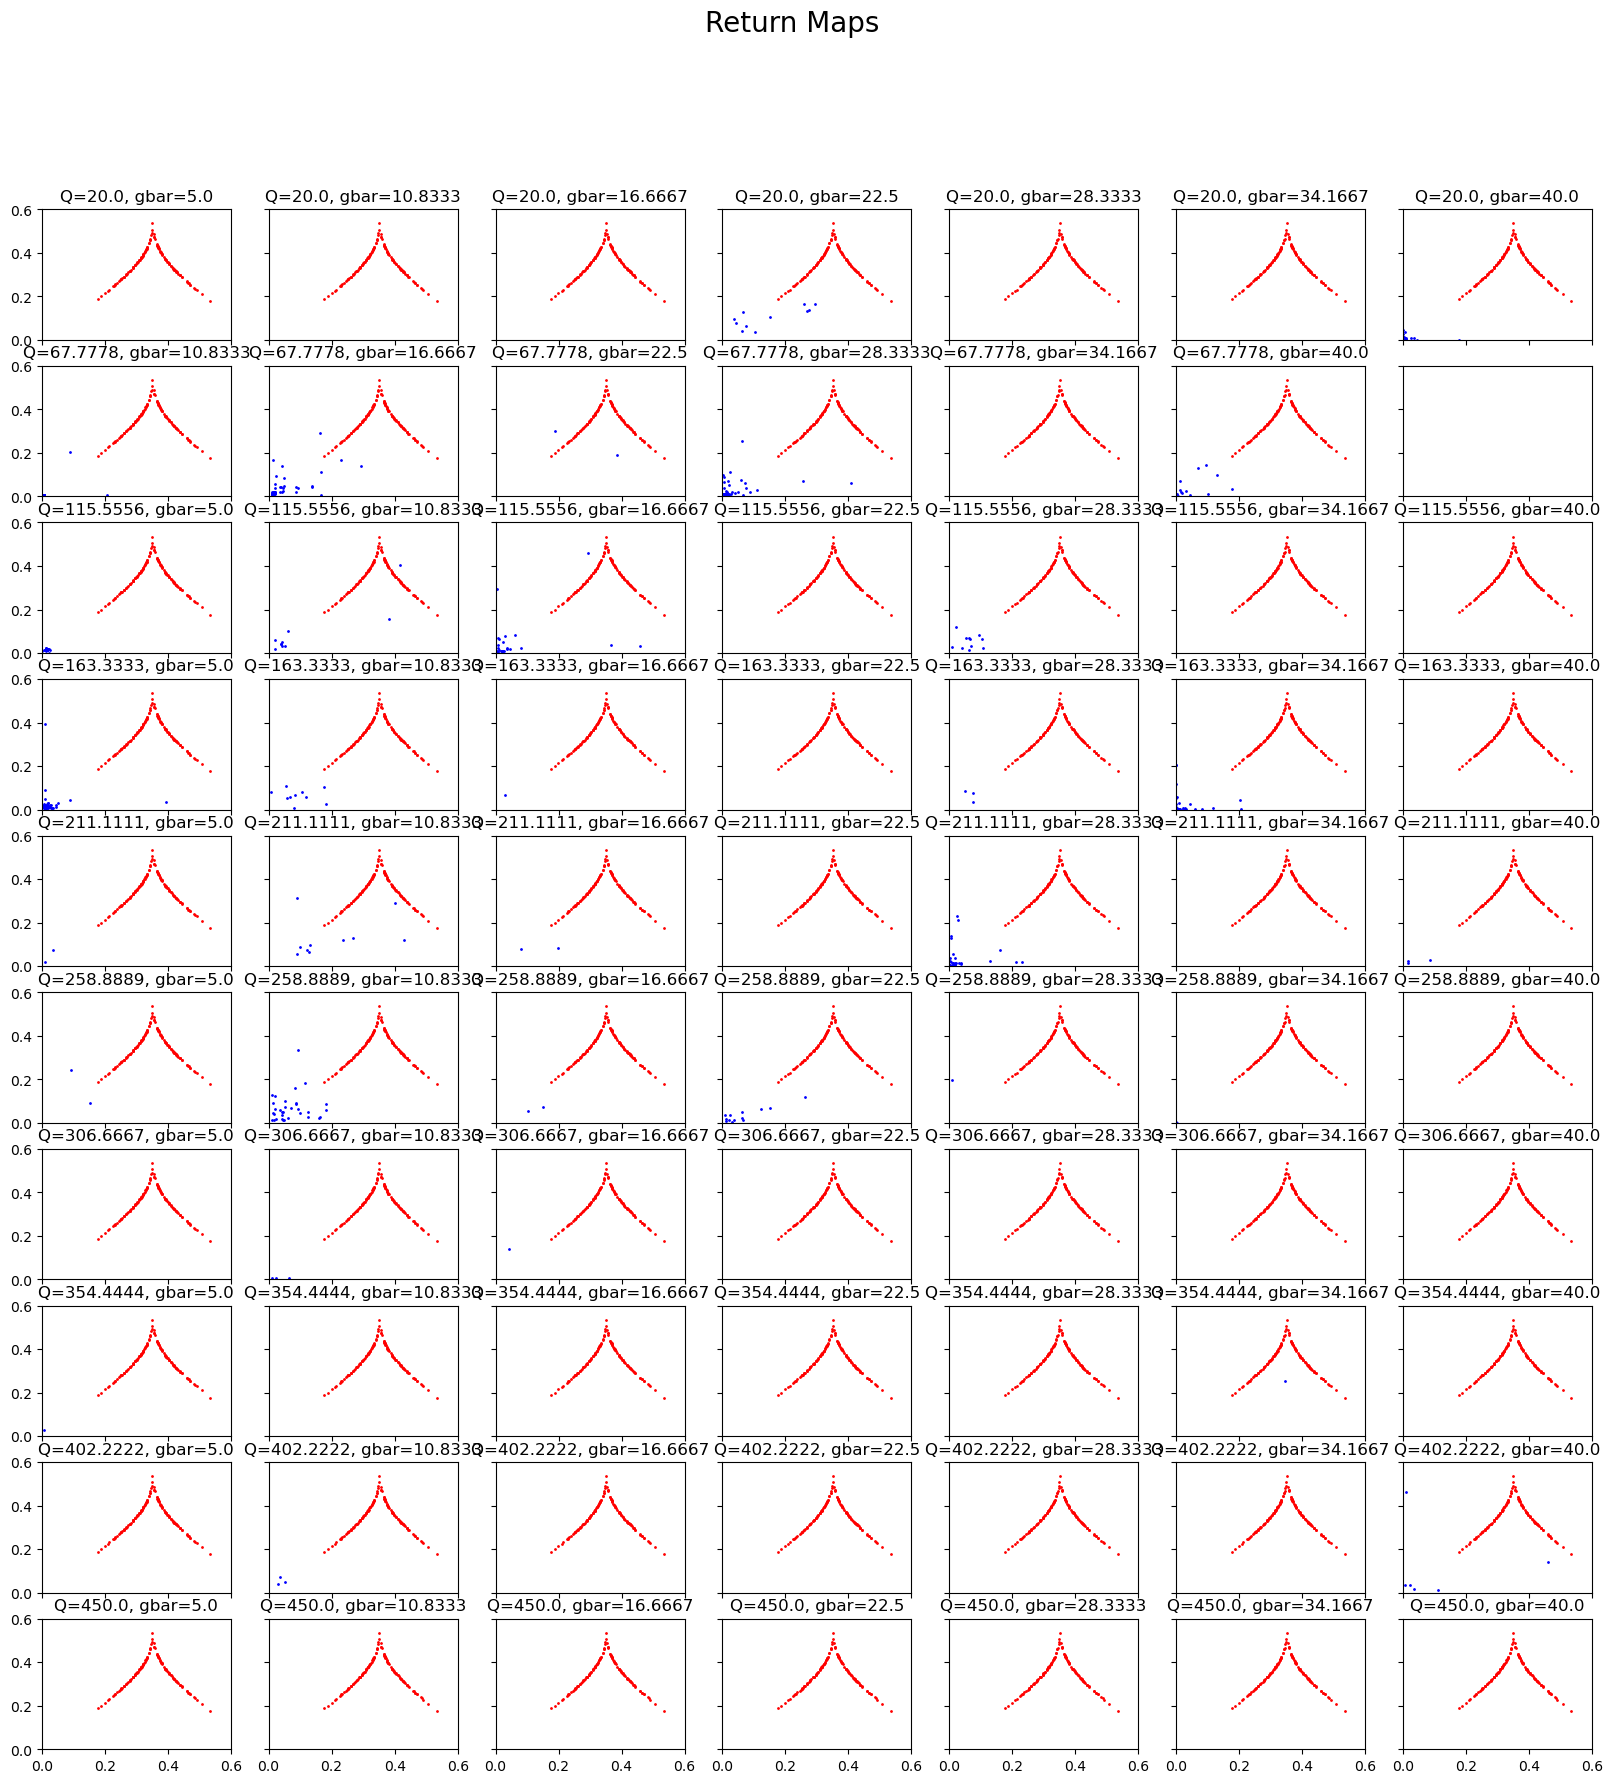

In [40]:
fig, ax = plt.subplots(len(total_stacked), len(total_stacked[0]), figsize=(20, 20), sharex=True, sharey=True)

for i in range(len(total_stacked)):
    for j in range(len(total_stacked[i])):
        data = total_stacked[i][j]
        ax[i, j].scatter(data['return_map'][0], data['return_map'][1], c='b', s=1)
        ax[i, j].scatter(original_return_map[0], original_return_map[1], c='r', s=1)
        ax[i, j].set_title(f"Q={data['Q']}, gbar={data['gbar']}")
plt.xlim(0, 0.6)
plt.ylim(0, 0.6)
plt.suptitle("Return Maps", fontsize=20)
plt.savefig(os.path.join(save_dir, 'return_maps.png'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
t = np.arange(total_data[0]['output'].shape[0]) * dt
fig, ax = plt.subplots(len(total_stacked), len(total_stacked[0]), figsize=(20, 20))

for i in range(len(total_stacked)):
    for j in range(len(total_stacked[i])):
        data = total_stacked[i][j]
        ax[i, j].plot(t, data['output'][:, 2], lw=.5)
        ax[i, j].set_title(f"Q={data['Q']}, gbar={data['gbar']}")
plt.savefig(os.path.join(save_dir, 'x_time_series.png'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
fig, ax = plt.subplots(len(total_stacked), len(total_stacked[0]), figsize=(20, 20))

for i in range(len(total_stacked)):
    for j in range(len(total_stacked[i])):
        data = total_stacked[i][j]
        ax[i, j].plot(sup[test_start:, 0], sup[test_start:, 1], lw=.5)
        ax[i, j].plot(data['output'][test_start:, 0], data['output'][test_start:, 1], lw=.5)
        ax[i, j].set_title(f"Q={data['Q']:.1f}, gbar={data['gbar']:.1f}")

plt.savefig(os.path.join(save_dir, 'x_y_phase_space.png'), dpi=300, bbox_inches='tight')
plt.show()

In [11]:
from typing import Union

def mean_squared_density_difference(data1, data2, axis:int=1, bins:Union[int, str, np.ndarray]=100):
    hists1 = np.array([np.histogram(data1[:, i], bins=bins, density=True)[0] for i in range(data1.shape[axis])])
    hists2 = np.array([np.histogram(data2[:, i], bins=bins, density=True)[0] for i in range(data2.shape[axis])])
    
    return np.mean((hists1 - hists2) ** 2)

In [12]:
axis = 1

mean_squared_density_difference(sup[test_start:, :], total_stacked[4][3]['output'][test_start:, :], axis=axis, bins=np.linspace(-.5, .5, 100))


0.07248272795828607

In [41]:
for i in range(len(total_stacked)):
    print(len(total_stacked[i]))

7
6
7
7
7
7
7
7
7
7


In [42]:
losses = [[total_stacked[i][j]['kl_div'] for j in range(len(total_stacked[i]))] for i in range(len(total_stacked))]
losses = np.array(losses)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (10,) + inhomogeneous part.

In [18]:
bins = np.linspace(-.5, .5, 201)
losses = [[mean_squared_density_difference(sup[test_start:, :], data['output'][test_start:, :], axis=axis, bins=bins) for data in lst] for lst in total_stacked]

losses = np.array(losses)

print(losses)
where = np.where(losses == np.min(losses))

print(where)
print(losses[where])

[[0.07127494 0.09848987 0.14896705 0.19649911 0.35981478 0.55305657
  0.37680101 0.34245318]
 [0.04849555 0.07814739 0.13632812 0.14797298 0.24215352 0.21416935
  0.20618714 0.46096308]
 [0.06397962 0.04217308 0.05275758 0.08876848 0.07583988 0.16834825
  0.22262067 0.46496798]
 [0.03995005 0.08836717 0.10458364 0.16278232 0.0743862  0.11087949
  0.10325424 0.14191537]
 [0.04896065 0.04352381 0.06387783 0.08142212 0.05888676 0.07166279
  0.09399743 0.11757383]
 [0.0707312  0.06515813 0.04895356 0.05308303 0.08927958 0.05263392
  0.07920773 0.07694338]]
(array([3]), array([0]))
[0.03995005]


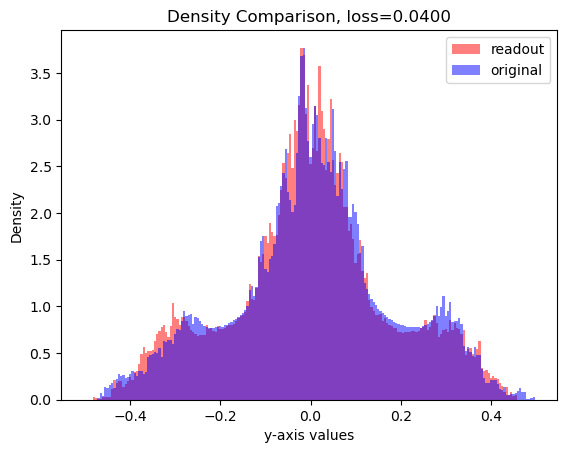

0.039950052469451054


In [17]:
hist, _ = np.histogram(total_stacked[where[0][0]][where[1][0]]['output'][test_start:, 1], bins=bins, density=True)
hist1, _ = np.histogram(sup[test_start:, 1], bins=bins, density=True)
plt.bar(bins[:-1], hist, width=bins[1]-bins[0], color='r', alpha=.5, label="readout")
plt.bar(bins[:-1], hist1, width=bins[1]-bins[0], color='b', alpha=.5, label="original")
plt.legend(loc=0)
plt.xlabel("y-axis values")
plt.ylabel("Density")
plt.title(f"Density Comparison, loss={losses[where[0][0], where[1][0]]:.4f}")
plt.savefig(os.path.join(save_dir, 'density_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()
print(mean_squared_density_difference(sup[test_start:, :], total_stacked[3][0]['output'][test_start:, :], axis=axis, bins=bins))

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (10,) + inhomogeneous part.

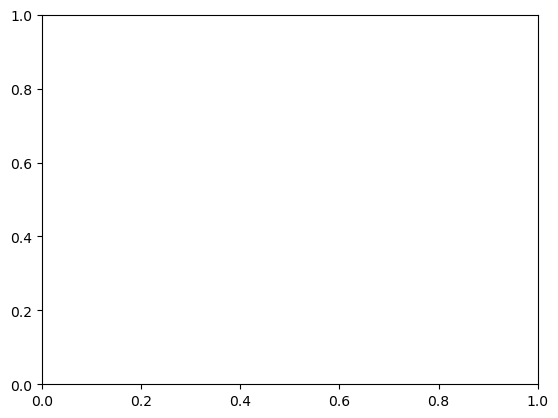

In [20]:
plt.pcolormesh(losses, cmap='viridis')
plt.colorbar(label="Mean Squared Density Difference")
plt.xticks(np.arange(losses.shape[1]), [data['gbar'] for data in total_stacked[0]])
plt.yticks(np.arange(losses.shape[0]), [data[0]['w_in_amp'] for data in total_stacked])
plt.xlabel("gbar")
plt.ylabel("Q")
plt.title("Density Loss Heatmap")
plt.savefig(os.path.join(save_dir, 'density_loss_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()